✅ pandas 함수/메서드 설명 및 예제

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'name': ['철수', '영희', '민수', '지수', '영수'],
    'gender': ['M', 'F', 'M', 'F', 'M'],
    'class': [1, 1, 2, 2, 1],
    'math': [80, 90, np.nan, 85, 70],
    'english': [85, 78, 95, 88, np.nan],
    'science': [82, 79, 91, 89, 77]
})

🔍 데이터 구조 확인

In [2]:
# 열 이름, 데이터 타입, 결측치 개수 출력
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     5 non-null      object 
 1   gender   5 non-null      object 
 2   class    5 non-null      int64  
 3   math     4 non-null      float64
 4   english  4 non-null      float64
 5   science  5 non-null      int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 372.0+ bytes


In [3]:
# 수치형 열에 대한 기본 통계량 요약
df.describe()

,class,math,english,science
count,5.000000,4.000000,4.000000,5.00000
mean,1.400000,81.250000,86.500000,83.60000
std,0.547723,8.539126,7.047458,6.14817
min,1.000000,70.000000,78.000000,77.00000
25%,1.000000,77.500000,83.250000,79.00000
50%,1.000000,82.500000,86.500000,82.00000
75%,2.000000,86.250000,89.750000,89.00000
max,2.000000,90.000000,95.000000,91.00000


In [4]:
df.head(2)

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79


In [5]:
df.tail(2)

,name,gender,class,math,english,science
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


🚫 결측치 처리

In [6]:
# 각 셀의 결측 여부 (True/False)
df.isna()

,name,gender,class,math,english,science
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,True,False,False
3,False,False,False,False,False,False
4,False,False,False,False,True,False


In [7]:
# 결측값을 0으로 대체
df.fillna(0)

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,0.0,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,0.0,77


In [8]:
df

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,NaN,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


# ★

In [9]:
# 결측값이 포함된 행(또는 열)을 삭제

# 하나라도 NaN이 있는 행 제거
df.dropna()

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
3,지수,F,2,85.0,88.0,89


In [10]:
# 특정 열에 대해 NaN이 있는 행만 제거
df.dropna(subset=['math'])

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


In [11]:
# 모든 값이 NaN인 행만 제거 (기본값)
df.dropna(how='all')

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,NaN,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


In [12]:
# NaN → -1 로 변경
df.replace({np.nan : -1})

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,-1.0,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,-1.0,77


➕ 파생 변수 및 열 추가

In [13]:
# 평균 점수 열 추가 (assign()은 새로운 열을 생성)
df.assign(mean_score = df[['math', 'english', 'science']].mean(axis=1))

,name,gender,class,math,english,science,mean_score
0,철수,M,1,80.0,85.0,82,82.333333
1,영희,F,1,90.0,78.0,79,82.333333
2,민수,M,2,NaN,95.0,91,93.000000
3,지수,F,2,85.0,88.0,89,87.333333
4,영수,M,1,70.0,NaN,77,73.500000


🔄 데이터 재구조화 (Reshaping)

In [14]:
df2 = pd.DataFrame({
    'student': ['A', 'A', 'B', 'B'],
    'subject': ['math', 'science', 'math', 'science'],
    'score': [90, 85, 80, 88]
})

df2

,student,subject,score
0,A,math,90
1,A,science,85
2,B,math,80
3,B,science,88


# ★

In [15]:
# 데이터를 '가로 테이블 형태'로 변형
df2.pivot(index='student', columns='subject', values='score')

subject,math,science
student,,
A,90,85
B,80,88


In [16]:
df3 = pd.DataFrame({
    'name': [['철수', '영희'], ['길동 ', '복자']],
    'hobbies': [['축구', '독서'], ['음악', '요리']]
})

df3

,name,hobbies
0,"[철수, 영희]","[축구, 독서]"
1,"[길동 , 복자]","[음악, 요리]"


### ★

In [17]:
# 리스트 항목을 행으로 펼쳐줌
df3.explode('name')

,name,hobbies
0,철수,"[축구, 독서]"
0,영희,"[축구, 독서]"
1,길동,"[음악, 요리]"
1,복자,"[음악, 요리]"


In [18]:
df3.explode('hobbies')

,name,hobbies
0,"[철수, 영희]",축구
0,"[철수, 영희]",독서
1,"[길동 , 복자]",음악
1,"[길동 , 복자]",요리


In [19]:
df3.explode(['name', 'hobbies'])

,name,hobbies
0,철수,축구
0,영희,독서
1,길동,음악
1,복자,요리


📊 집계 및 그룹 연산

In [20]:
df

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,NaN,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


# ★

In [21]:
# 지정한 컬럼 기준으로 데이터를 그룹화하고, 평균, 합계 등 집계 연산 수행

# 학급(class)별 평균 점수 계산
df.groupby('class').mean(numeric_only=True)

,math,english,science
class,,,
1,80.0,81.5,79.333333
2,85.0,91.5,90.000000


In [22]:
# 성별별 수학 점수 평균
df.groupby('gender')['math'].mean()

gender
F    87.5
M    75.0
Name: math, dtype: float64

In [23]:
# 그룹별 여러 집계 함수 적용
df.groupby('class').agg(
    math_avg=('math', 'mean'),
    eng_max=('english', 'max'),
    count=('name', 'count')
)

,math_avg,eng_max,count
class,,,
1,80.0,85.0,3
2,85.0,95.0,2


In [24]:
# 여러 열에 여러 함수 적용
df.agg({'math': 'mean', 'science': 'sum'})

math        81.25
science    418.00
dtype: float64

In [25]:
df_int = pd.DataFrame({'A': [1, 2, 3], 'B': [10, 20, 30]})

df_int

,A,B
0,1,10
1,2,20
2,3,30


### ★

In [26]:
# 모든 행에 사용자 함수 적용
print(df_int.apply(lambda x: x.max() - x.min()),'\n')
print(df_int.apply(lambda x: x.max() - x.min(), axis=1),'\n')

print(df_int.apply(lambda x: x.mean(), axis=0),'\n')
print(df_int.apply(lambda x: x.mean(), axis=1),'\n')

# df.sum()
print(df_int.apply(sum),'\n')

# df.sum(axis=1)
print(df_int.apply(sum, axis=1))

A     2
B    20
dtype: int64 

0     9
1    18
2    27
dtype: int64 

A     2.0
B    20.0
dtype: float64 

0     5.5
1    11.0
2    16.5
dtype: float64 

A     6
B    60
dtype: int64 

0    11
1    22
2    33
dtype: int64


In [27]:
df['math']

0    80.0
1    90.0
2     NaN
3    85.0
4    70.0
Name: math, dtype: float64

In [28]:
df['math'].apply(lambda x : x * 5)

0    400.0
1    450.0
2      NaN
3    425.0
4    350.0
Name: math, dtype: float64

📋 정렬, 필터링, 샘플링

In [29]:
# 영어 점수 기준 정렬
df.sort_values('english')

,name,gender,class,math,english,science
1,영희,F,1,90.0,78.0,79
0,철수,M,1,80.0,85.0,82
3,지수,F,2,85.0,88.0,89
2,민수,M,2,NaN,95.0,91
4,영수,M,1,70.0,NaN,77


In [30]:
# 인덱스 기준 정렬
df.sort_index()

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,NaN,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


In [31]:
# 무작위 40% 샘플 추출
df.sample(frac=0.4, random_state=1)

,name,gender,class,math,english,science
2,민수,M,2,NaN,95.0,91
1,영희,F,1,90.0,78.0,79


# ★

In [32]:
# DataFrame에서 SQL처럼 문자열 조건으로 데이터를 필터링할 수 있음

# 평균이 80점 이상인 학생 추출
df.query("math >= 80")

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
3,지수,F,2,85.0,88.0,89


In [33]:
# 여러 조건 결합 (수학 80 이상 AND 영어 85 이상)
df.query("math >= 80 and english >= 85")

,name,gender,class,math,english,science
0,철수,M,1,80.0,85.0,82
3,지수,F,2,85.0,88.0,89


In [34]:
# 문자열 조건 (성별이 'F'인 경우)
df.query("gender == 'F'")

,name,gender,class,math,english,science
1,영희,F,1,90.0,78.0,79
3,지수,F,2,85.0,88.0,89


🧾 열/행 요약 함수

In [35]:
# 각 성별의 빈도
df['gender'].value_counts()

gender
M    3
F    2
Name: count, dtype: int64

### ★

In [36]:
# 평균 / 합계 / 개수
print(df['math'].mean())
print(df['science'].sum())
print(df['english'].count())

81.25
418
4


🧠 기타 기능

### ★

In [37]:
# DataFrame 전체를 딕셔너리로 변환
data = df.to_dict()
data

{'name': {0: '철수', 1: '영희', 2: '민수', 3: '지수', 4: '영수'},
 'gender': {0: 'M', 1: 'F', 2: 'M', 3: 'F', 4: 'M'},
 'class': {0: 1, 1: 1, 2: 2, 3: 2, 4: 1},
 'math': {0: 80.0, 1: 90.0, 2: nan, 3: 85.0, 4: 70.0},
 'english': {0: 85.0, 1: 78.0, 2: 95.0, 3: 88.0, 4: nan},
 'science': {0: 82, 1: 79, 2: 91, 3: 89, 4: 77}}

In [38]:
print(data['name'])
print(data['name'][2])

print(data['math'])
print(data['math'][2])

{0: '철수', 1: '영희', 2: '민수', 3: '지수', 4: '영수'}
민수
{0: 80.0, 1: 90.0, 2: nan, 3: 85.0, 4: 70.0}
nan


In [39]:
# 지정 열들의 총합 반환
df[['math', 'english', 'science']].sum()

math       325.0
english    346.0
science    418.0
dtype: float64

In [40]:
# 열 이름 변경
df.rename(columns={'math': '수학'})

,name,gender,class,수학,english,science
0,철수,M,1,80.0,85.0,82
1,영희,F,1,90.0,78.0,79
2,민수,M,2,NaN,95.0,91
3,지수,F,2,85.0,88.0,89
4,영수,M,1,70.0,NaN,77


In [41]:
# 각 값의 빈도 수 확인 (예: 성별 분포, 반 인원 수)
df['gender'].value_counts()
df['class'].value_counts()

class
1    3
2    2
Name: count, dtype: int64

In [42]:
# pandas 출력 형식 설정 (소수점 2자리)
pd.set_option('display.float_format', '{:.2f}'.format)

### ★

In [43]:
# DataFrame을 HTML 테이블 형태의 문자열로 변환
html_table = df.to_html()
print(html_table)

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>name</th>
      <th>gender</th>
      <th>class</th>
      <th>math</th>
      <th>english</th>
      <th>science</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>철수</td>
      <td>M</td>
      <td>1</td>
      <td>80.00</td>
      <td>85.00</td>
      <td>82</td>
    </tr>
    <tr>
      <th>1</th>
      <td>영희</td>
      <td>F</td>
      <td>1</td>
      <td>90.00</td>
      <td>78.00</td>
      <td>79</td>
    </tr>
    <tr>
      <th>2</th>
      <td>민수</td>
      <td>M</td>
      <td>2</td>
      <td>NaN</td>
      <td>95.00</td>
      <td>91</td>
    </tr>
    <tr>
      <th>3</th>
      <td>지수</td>
      <td>F</td>
      <td>2</td>
      <td>85.00</td>
      <td>88.00</td>
      <td>89</td>
    </tr>
    <tr>
      <th>4</th>
      <td>영수</td>
      <td>M</td>
      <td>1</td>
      <td>70.00</td>
      <td>NaN</td>
      <td>77</td>
    </tr>
  </t

In [44]:
# 문자열 형식의 날짜 데이터
data = {
    'name': ['A', 'B', 'C'],
    'birth': ['2000-01-01', '1995-05-23', '1999-12-31']
}

df = pd.DataFrame(data)

# 문자열 → datetime 변환
df['birth'] = pd.to_datetime(df['birth'])

# datetime 타입 확인
print(df, '\n')
print(df.dtypes)

  name      birth
0    A 2000-01-01
1    B 1995-05-23
2    C 1999-12-31 

name             object
birth    datetime64[ns]
dtype: object


✅ Seaborn & Matplotlib 시각화

🎨 Seaborn 시각화 함수

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = sns.load_dataset("titanic")

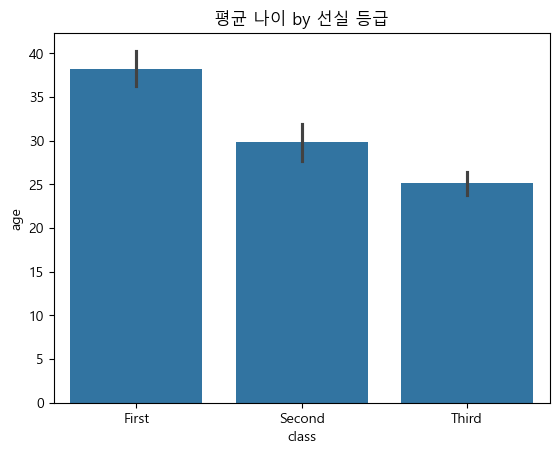

In [46]:
# 범주형 변수에 대한 평균값 또는 집계값 시각화
sns.barplot(x='class', y='age', data=df)

plt.title("평균 나이 by 선실 등급")
plt.show()

# ★

### 이상치(Outlier) 기준 - IQR 방식

Q1: 1사분위수 (25%)

Q3: 3사분위수 (75%)

IQR = Q3 - Q1

이상치 범위 -> 점(●) 으로 표시

* 아래쪽 이상치 : Q1 - 1.5 * IQR 보다 작은 값

* 위쪽 이상치 : Q3 + 1.5 * IQR 보다 큰 값

In [47]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1
print(f'Q1값 : {Q1} , Q3값 : {Q3} , IQR 값 : {IQR}\n')

outliers = df[(df['age'] < Q1 - 1.5 * IQR) | (df['age'] > Q3 + 1.5 * IQR)]
print(outliers['age'])

Q1값 : 20.125 , Q3값 : 38.0 , IQR 값 : 17.875

33    66.00
54    65.00
96    71.00
116   70.50
280   65.00
456   65.00
493   71.00
630   80.00
672   70.00
745   70.00
851   74.00
Name: age, dtype: float64


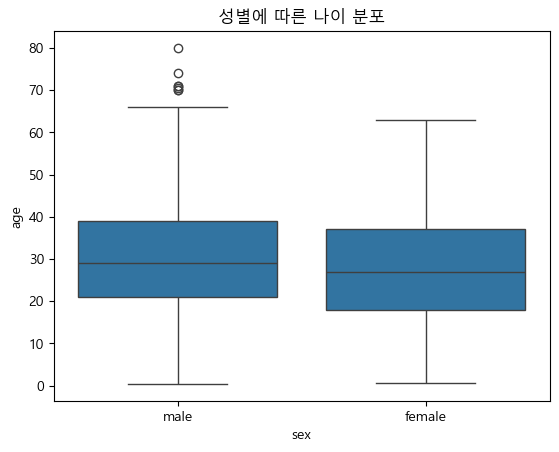

In [48]:
# 분포, 중앙값, 이상치를 포함한 시각적 요약
sns.boxplot(x='sex', y='age', data=df)

plt.title("성별에 따른 나이 분포")
plt.show()

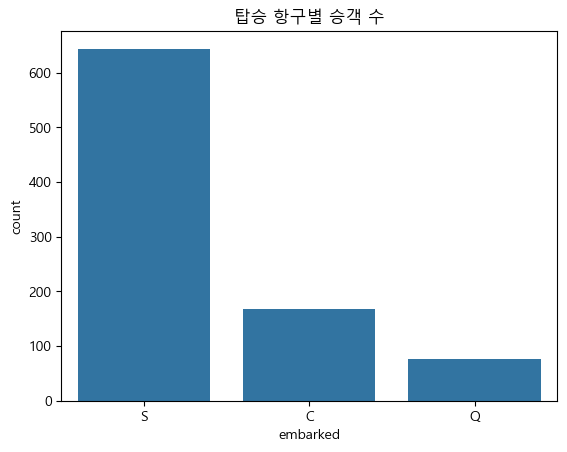

In [49]:
# 범주형 변수의 빈도(개수)를 막대그래프로 표현
sns.countplot(x='embarked', data=df)

plt.title("탑승 항구별 승객 수")
plt.show()

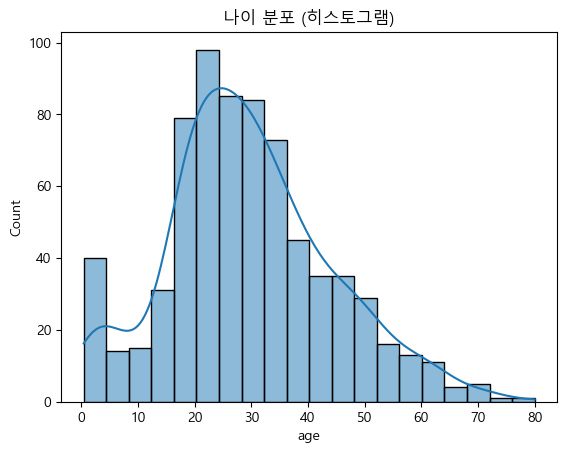

In [50]:
# 연속형 변수의 분포를 히스토그램으로 시각화
sns.histplot(df['age'], bins=20, kde=True)

plt.title("나이 분포 (히스토그램)")
plt.show()

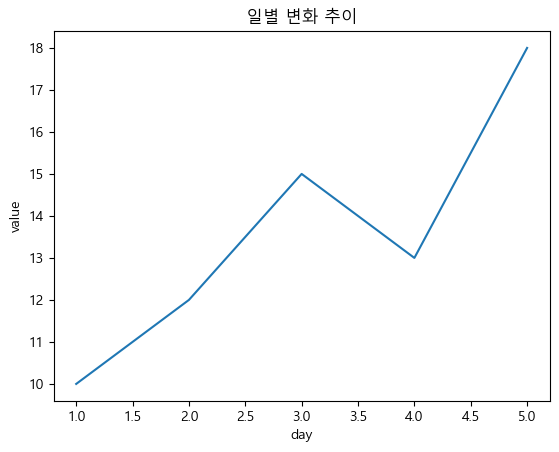

In [51]:
time_df = pd.DataFrame({'day': [1, 2, 3, 4, 5], 'value': [10, 12, 15, 13, 18]})

# 시간 흐름 등 연속적인 값 변화 시각화
sns.lineplot(x='day', y='value', data=time_df)

plt.title("일별 변화 추이")
plt.show()

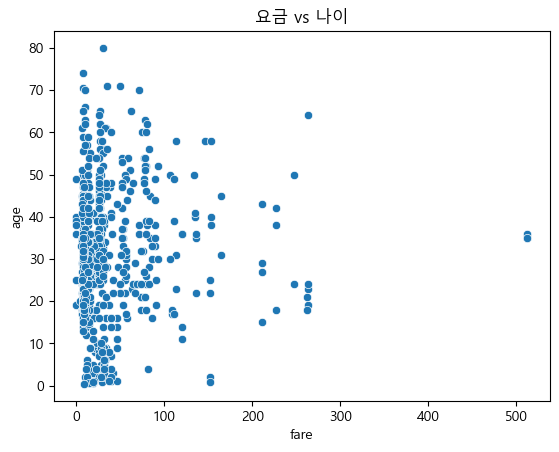

In [52]:
# 두 연속형 변수 간의 관계 시각화 (산점도)
sns.scatterplot(x='fare', y='age', data=df)

plt.title("요금 vs 나이")
plt.show()

🖼️ Matplotlib 시각화 기능

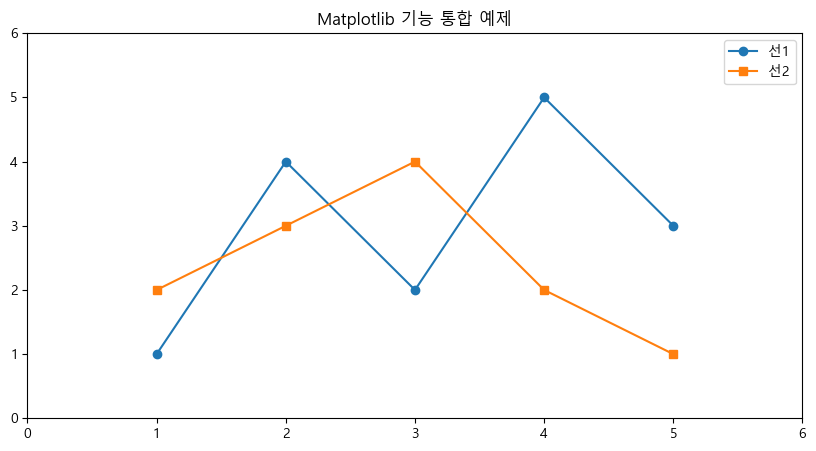

In [53]:
# 전체 스타일 설정
'''
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (8, 5)
})
'''

# 새로운 그림 생성 (크기 지정 포함)
plt.figure(figsize=(10, 5))

# 선 그래프 2개
x = [1, 2, 3, 4, 5]
y1 = [1, 4, 2, 5, 3]
y2 = [2, 3, 4, 2, 1]
plt.plot(x, y1, label='선1', marker='o')
plt.plot(x, y2, label='선2', marker='s')

# 범례 추가
plt.legend()

# 축 범위 설정
plt.axis([0, 6, 0, 6])

# 제목
plt.title("Matplotlib 기능 통합 예제")

# 출력
plt.show()

✅ 텍스트 마이닝 & 워드클라우드

🔠 1. 형태소 분석기 (konlpy)

In [54]:
from konlpy.tag import Okt

okt = Okt()
text = "데이터 분석은 정말 재미있다!"

# 명사만 추출
nouns = okt.nouns(text)
print("명사:", nouns)

# 형태소 분리
morphs = okt.morphs(text)
print("형태소:", morphs)

# 품사 태깅
pos = okt.pos(text)
print("품사 태깅:", pos)

명사: ['데이터', '분석', '정말']
형태소: ['데이터', '분석', '은', '정말', '재미있다', '!']
품사 태깅: [('데이터', 'Noun'), ('분석', 'Noun'), ('은', 'Josa'), ('정말', 'Noun'), ('재미있다', 'Adjective'), ('!', 'Punctuation')]


In [55]:
from konlpy.tag import Kkma

kkma = Kkma()
text = "데이터 분석은 정말 재미있다!"

print("명사:", kkma.nouns(text))
print("형태소:", kkma.morphs(text))
print("품사 태깅:", kkma.pos(text))

명사: ['데이터', '분석']
형태소: ['데이터', '분석', '은', '정말', '재미있', '다', '!']
품사 태깅: [('데이터', 'NNG'), ('분석', 'NNG'), ('은', 'JX'), ('정말', 'MAG'), ('재미있', 'VA'), ('다', 'EFN'), ('!', 'SF')]


In [56]:
from konlpy.tag import Hannanum

hannanum = Hannanum()
text = "데이터 분석은 정말 재미있다!"

print("명사:", hannanum.nouns(text))
print("형태소:", hannanum.morphs(text))
print("품사 태깅:", hannanum.pos(text))

명사: ['데이터', '분석']
형태소: ['데이터', '분석', '은', '정말', '재미있', '다', '!']
품사 태깅: [('데이터', 'N'), ('분석', 'N'), ('은', 'J'), ('정말', 'M'), ('재미있', 'P'), ('다', 'E'), ('!', 'S')]


🧹 2. 텍스트 전처리

In [57]:
import re

text = "안녕하세요!! 파이썬(PYTHON)을 활용한 텍스트 분석@@ 재미있죠??"

# 특수문자 제거
text_clean = re.sub(r'[^가-힣a-zA-Z\s]', '', text)

# 소문자 변환
text_lower = text_clean.lower()

# 특정 단어 제거
text_final = text_lower.replace("분석", "")

print(f'기존 문자열 : {text} \n')
print(f'특수문자 제거 : {text_clean} \n')
print(f'소문자 변환 : {text_lower} \n')
print(f'특정 단어 제거 : {text_final}')

기존 문자열 : 안녕하세요!! 파이썬(PYTHON)을 활용한 텍스트 분석@@ 재미있죠?? 

특수문자 제거 : 안녕하세요 파이썬PYTHON을 활용한 텍스트 분석 재미있죠 

소문자 변환 : 안녕하세요 파이썬python을 활용한 텍스트 분석 재미있죠 

특정 단어 제거 : 안녕하세요 파이썬python을 활용한 텍스트  재미있죠


🎨 3. 워드클라우드 생성

In [58]:
from PIL import Image
icon = Image.open('./data/cloud.png')

img = Image.new('RGB', icon.size, (255, 255, 255))
img.paste(icon, icon)

img = np.array(img)

# ★

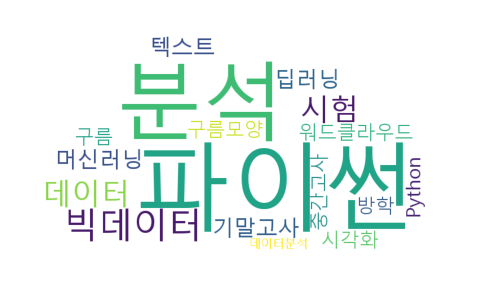

In [59]:
from wordcloud import WordCloud

text = "파이썬 데이터 분석 파이썬 머신러닝 딥러닝 텍스트 파이썬 분석 분석 빅데이터 시험 기말고사 데이터 파이썬 빅데이터 워드클라우드 구름 시각화 구름모양 Python 중간고사 시험 방학 데이터분석 빅데이터 파이썬 분석"

# 워드클라우드 생성
# ✅ 예제 1: 문자열에서 직접 생성
wc = WordCloud(font_path='malgun.ttf', background_color='white', width=400, height=400, mask = img)
imgWC = wc.generate(text)

# 시각화
plt.figure(figsize=(6, 4))
plt.axis('off')
plt.imshow(imgWC)
plt.show()

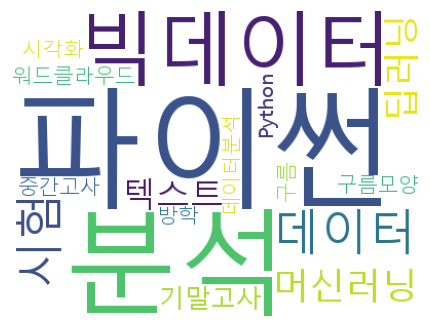

In [60]:
from collections import Counter

words = ['파이썬', '데이터', '분석', '파이썬', '머신러닝', '딥러닝', '텍스트', '파이썬', '분석', '분석', '빅데이터', '시험', '기말고사', '데이터', '파이썬', '빅데이터', '워드클라우드', '구름', '시각화', '구름모양', 'Python', '중간고사', '시험', '방학', '데이터분석', '빅데이터', '파이썬', '분석']
word_freq = Counter(words)

# ✅ 예제 2: 단어 빈도 dict를 기반으로 생성
wc = WordCloud(font_path='malgun.ttf', background_color='white', width=400, height=300)
imgWC = wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(6, 4))
plt.axis('off')
plt.imshow(imgWC)
plt.show()

✅ NumPy 및 조건 처리

In [61]:
a = np.array([1, 2, 3, 4])

print("배열:", a)

배열: [1 2 3 4]


In [62]:
data = np.array([1, 2, np.nan, 4])
print("결측 포함 배열:", data)

# 평균 계산 시 오류 발생
# print(np.mean(data))  # 에러 발생 가능

# 결측 무시 평균 계산
print("결측 무시 평균:", np.nanmean(data))

결측 포함 배열: [ 1.  2. nan  4.]
결측 무시 평균: 2.3333333333333335


In [63]:
score = np.array([85, 70, 90, 60, 95])
grade = np.where(score >= 80, "합격", "불합격")

print("결과:", grade)

결과: ['합격' '불합격' '합격' '불합격' '합격']


In [64]:
df = pd.DataFrame({
    'name': ['A', 'B', 'C', 'D'],
    'score': [85, 72, 60, 95]
})

# 조건 처리: 80점 이상
high_scores = df[df['score'] >= 80]
print("80점 이상\n", high_scores)

80점 이상
   name  score
0    A     85
3    D     95


In [65]:
df['result'] = np.where(df['score'] >= 80, 'Pass', 'Fail')
print(df)

  name  score result
0    A     85   Pass
1    B     72   Fail
2    C     60   Fail
3    D     95   Pass
